# SIT374/SIT764 Capstone Team Project
### Jack Montgomery-Parkes :: S223232288@deakin.edu.au
## Audio for Machine Learning

When we capture sound for machine learning we're doing something that sound engineers have been doing for as long as digital recording has existed: turning pressure changes in the air into a list of numbers, and then deciding what representation of those numbers actually carries the information we care about. The choices we make at each step matter, the same way that mic choice, gain staging, and instrument position matter in a recording session.

This notebook walks through that chain as it pertains to ML. We'll use `librosa` (the standard Python toolkit for audio analysis) along with `numpy`, `scipy.signal` for filter work, and `matplotlib` for visual analysis. The approach is conceptual rather than mathematical. I'm coming off the back of multiple mathematics assignments and my brain hurts, so I'm deliberately avoiding formulas in favour of intuition. The engineers I've worked with in the past and found to be most effective are the ones who can hear a problem before they can name its equation.

**By the end of this you should be comfortable with:**

- What digital audio actually is, and the role of sample rate
- Reading the waveform and assessing what's in it
- Frequency analysis with the FFT
- Spectrograms, and the trade-off between time and frequency resolution
- Mel spectrograms, and why our hearing dictates the representation we feed to a model
- Filters as preprocessing
- Dynamic range, normalisation, and the difference from "compression"
- The complete feature pipeline used in the benchmarking notebook

This notebook is the companion to the Project Echo benchmarking notebook. Where that one compares model architectures, this one steps back to the input side: how the audio feeding those models is captured, transformed, and turned into the Mel spectrograms the benchmarks consume. It's meant as an entry point for new students joining the Project Echo Engine team. If the benchmarking notebook ever has you wondering what a Mel spectrogram actually is, and why we're feeding pictures of sound to an image model, this is where that intuition gets built.


## Setup

Three libraries. `librosa` for audio I/O and analysis, `scipy` for filter design, `matplotlib` for plots. `IPython.display.Audio` lets us listen to clips inline, which I'd encourage you to do at every step, if you're able. The ear is the sense we scrutinise sound with.


In [8]:
# !pip install librosa scipy matplotlib


In [6]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from IPython.display import Audio, display

# Prettier plots
plt.rcParams["figure.figsize"] = (10, 3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Ready.")


Ready.


## 1. What is Digital Audio?

Sound is a pressure wave moving through air. To store it on a computer we measure that pressure thousands of times per second and write each measurement down. An audio file, fundamentally, is just a long list of numbers.

Two pieces of metadata define how to read that list back as sound. **Sample rate** is how many measurements per second, in Hertz. CD audio is 44,100 Hz, most ML pipelines use 16, 22.05, or 32kHz. **Bit depth** is the precision of each measurement; we almost always convert to 32-bit floats on load, which scales each sample into the range \[-1.0, 1.0\].

There's one related concept worth absorbing before we go further: a signal sampled at rate $f$ can faithfully represent frequencies up to $f/2$, and not a Hertz higher. Sample at 48kHz and your usable bandwidth tops out at 24kHz, which is comfortably above what any human listeners can hear. Sample at 22.05kHz and you cap at around 11kHz, which is fine for speech but marginal for music or for sources that contain useful detail above that. The instinct to develop here is to ask what the highest frequency of interest in your source is, double it, and use that as your sample rate.


### A sine wave from scratch

Before we open a real recording, let's build the simplest signal that exists. There's value in seeing this, as once you've made a sine wave from an array of numbers and heard it play back, you can't quite unsee that an audio file is just a sequence of measurements someone chose to interpret as sound.


In [4]:
sr = 22050  # Half the old CD redbook standard
duration = 2.0
freq = 440 # Standard concert tuning pitch in hertz

t = np.linspace(0, duration, int(sr * duration), endpoint=False)
y_sine = 0.3 * np.sin(2 * np.pi * freq * t)

print(f"y_sine is a numpy array of shape {y_sine.shape} and dtype {y_sine.dtype}")
print(f"First 5 samples: {y_sine[:5]}")
print(f"Range: [{y_sine.min():.3f}, {y_sine.max():.3f}]")

Audio(y_sine, rate=sr)


y_sine is a numpy array of shape (44100,) and dtype float64
First 5 samples: [0.         0.03751516 0.07444135 0.11019888 0.14422636]
Range: [-0.300, 0.300]


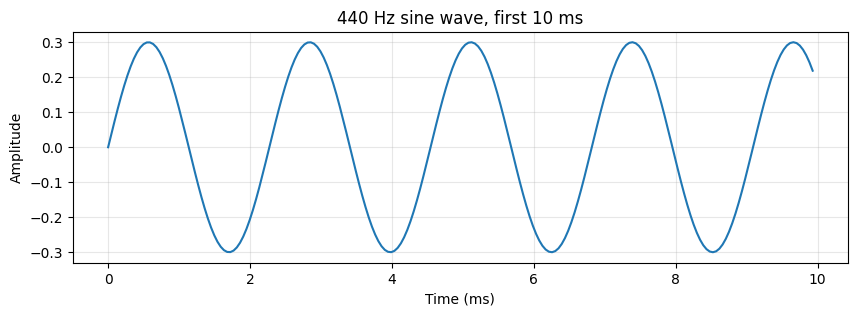

In [9]:
# Zoom in on the first 10 milliseconds to see individual cycles
n_samples = int(0.01 * sr)
plt.plot(t[:n_samples] * 1000, y_sine[:n_samples])
plt.xlabel("Time (ms)"); plt.ylabel("Amplitude")
plt.title(f"{freq} Hz sine wave, first 10 ms")
plt.show()


Count the cycles in that 10 ms window, there should find a touch over four. That's exactly what 440 Hz means: 440 cycles per second, so 4.4 cycles per 10 ms. The connection between "frequency" and the literal shape of the waveform is right there on the page.

Listen to the output. It's a single, pure tone. Uncomplicated, unbothered, no additional harmonics. It's what a test oscillator sounds like, not what an instrument sounds like. Real signals are far messier and far more interesting. We'll get to those.

### Loading a real audio file

`librosa.load` is the workhorse for audio I/O. It returns the audio as a numpy array and the sample rate, sums to mono by default, converts to floating point, and resamples to a target rate if you ask it to. We'll use `librosa.ex('trumpet')`, a short clip of solo trumpet that ships with the library.


In [29]:
y, sr = librosa.load(librosa.ex("trumpet"), sr=22050)

print(f"Shape: {y.shape}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y) / sr:.2f} seconds")
print(f"Range: [{y.min():.3f}, {y.max():.3f}]")

Audio(y, rate=sr)


Shape: (117601,)
Sample rate: 22050 Hz
Duration: 5.33 seconds
Range: [-0.685, 0.632]


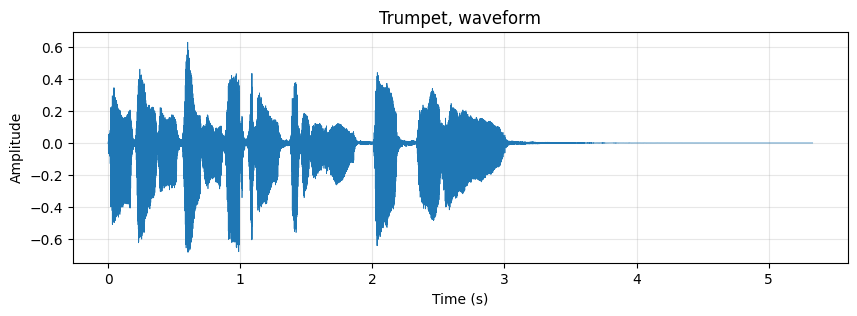

In [11]:
times = np.arange(len(y)) / sr
plt.plot(times, y, linewidth=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.title("Trumpet, waveform")
plt.show()


The waveform tells a story even at this distance. The sharp leading edges are note, or transient attacks. The fuller stretches in the middle of each note are the sustained tone. The trailing edges are decays. You can read a lot from a waveform before ever auditioning the clip. This is worth keeping in the back of your mind when we start working with ML models that learn from visual inputs; already we can tell something about the audio just from looking at a graphical representation of it.

One detail worth flagging early. `librosa.load` resamples to 22050 Hz and sums to mono by default. For ML work I'd always pass `sr=` explicitly so everyone working on the project is using the same rate end-to-end. A sample-rate mismatch between training and inference is an easy mistake to make and one that can be hard to diagnose from output alone.


## 2. Reading the Waveform

Before transforming anything, it pays to assess what's already there. Three measurements come up constantly.

**Peak amplitude** is the largest absolute value in the clip. If it sits at exactly 1.0 the clip has *clipped*. That is, somewhere in the chain a sample was driven past the maximum (sometimes called the digital ceiling) and got chopped off, or truncated. Clipping is unrecoverable; the information above the limit is gone.

**RMS (root-mean-square)** is the average volume level over time. It correlates much better with perceived loudness than peak does, because brief spikes don't fool it. LUFS is a common way to measure this, particularly using the EBU-128 broadcast standard common in the UK and Europe.

**Decibels** are the logarithmic loudness scale. Human hearing is logarithmic. That is, a doubling of pressure isn't heard as a doubling of loudness. `librosa.amplitude_to_db` does the conversion. "dBFS" means "decibels relative to full scale", where 0 dBFS is amplitude 1.0 and everything else is negative.


In [12]:
peak = np.max(np.abs(y))
rms = np.sqrt(np.mean(y ** 2))
rms_db = librosa.amplitude_to_db(np.array([rms]))[0]

print(f"Peak amplitude: {peak:.3f}")
print(f"RMS amplitude: {rms:.3f}")
print(f"RMS in dBFS: {rms_db:.1f} dB")


Peak amplitude: 0.685
RMS amplitude: 0.077
RMS in dBFS: -22.3 dB


A single RMS value for an entire clip is useful as a summary, but it's far more revealing as a function of time. This tells us the **amplitude envelope** of the signal, computed in short overlapping windows.


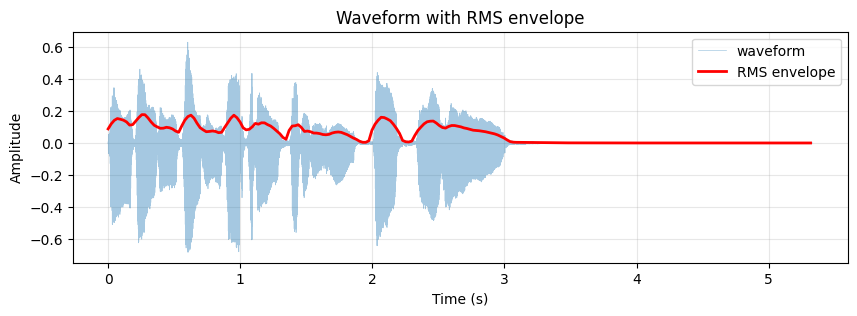

In [14]:
# Frame-level RMS: one value per ~23ms window at sr=22050
rms_t = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
frame_times = librosa.frames_to_time(np.arange(len(rms_t)), sr=sr, hop_length=512)

fig, ax = plt.subplots()
ax.plot(times, y, alpha=0.4, linewidth=0.5, label="waveform")
ax.plot(frame_times, rms_t, color="red", linewidth=2, label="RMS envelope")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude")
ax.set_title("Waveform with RMS envelope")
ax.legend()
plt.show()


The red trace is the envelope, and it's full of information: note onsets, sustains, decays, the overall dynamic shape. But notice what it lacks? If you fed only this envelope to a model, it could tell you *when* things happen and *how loud*, but nothing about pitch or timbre. For that we need to look inside the signal in the frequency domain.


## 3. Looking at the Frequencies

The waveform tells us how loud the signal is at each instant. To know *what* the signal is, that is, what notes are in it, what harmonics, what character, we need to look at it in the frequency domain. The default tool for this is the **Fast Fourier Transform**, and it's the most useful single analytical tool we have in digital audio.

The way to think about an FFT is that it compares your signal against sine waves of many different frequencies and reports how much of each frequency is present. The output is one complex number per frequency bin; we use the magnitude, basically asking "how much of this frequency exists in the signal" over and over again, discarding the phase. 

### A sanity check first

Our 440 Hz sine wave from earlier contains, by design, nothing but a 440 Hz sine wave. The FFT should report exactly one peak at 440 Hz.


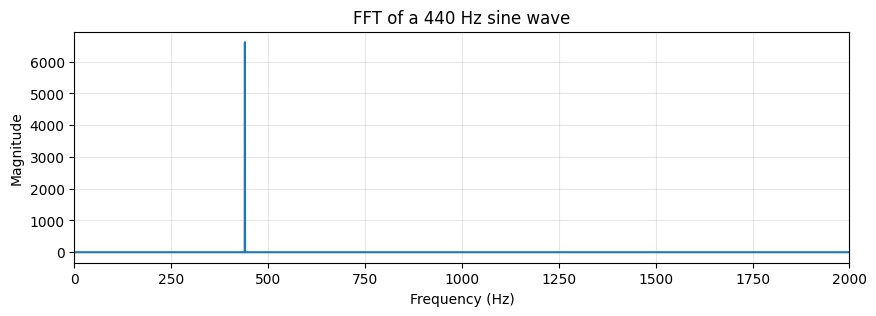

Peak frequency: 440.0 Hz


In [15]:
Y = np.fft.rfft(y_sine)
magnitude = np.abs(Y)
freqs = np.fft.rfftfreq(len(y_sine), d=1/sr)

plt.plot(freqs, magnitude)
plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude")
plt.title("FFT of a 440 Hz sine wave")
plt.show()

peak_idx = np.argmax(magnitude)
print(f"Peak frequency: {freqs[peak_idx]:.1f} Hz")


Yerp. One peak, exactly at 440 Hz. The FFT has correctly identified what's in the signal.

### A trumpet under analysis

A trumpet playing a single note produces something far richer (and more annoying) than a simple sine wave. The vibrating column of air supports a **fundamental** frequency (the perceived pitch, or formant) along with a series of **harmonics** at integer multiples of that fundamental. The relative levels of those harmonics are what give the trumpet its characteristic bright, brassy sound. Strip these away and you'd be left with something closer to a flute (still annoying but less so).

The harmonic content is also where most of the information for instrument identification lives. Two instruments playing the same note are distinguishable to the ear precisely because their harmonic content differs. Importantly for us, they're distinguishable to a model for exactly the same reason.


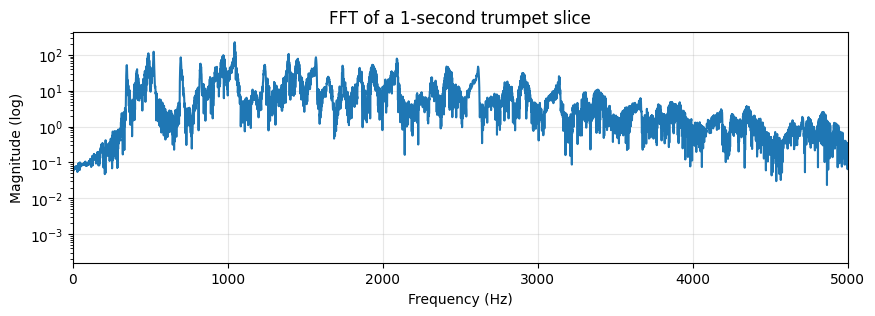

In [16]:
# 1-second slice from the middle of a sustained note
slice_start = int(1.0 * sr)
slice_len = int(1.0 * sr)
y_slice = y[slice_start : slice_start + slice_len]

Y_slice = np.fft.rfft(y_slice)
mag_slice = np.abs(Y_slice)
freqs_slice = np.fft.rfftfreq(len(y_slice), d=1/sr)

# Log y-axis, harmonic levels span a huge range
plt.semilogy(freqs_slice, mag_slice)
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude (log)")
plt.title("FFT of a 1-second trumpet slice")
plt.show()


The harmonic series is laid out in front of you. The leftmost, or lowest peak, is typically the fundamental, and you can count the regularly spaced peaks marching up through the spectrum. A bright instrument like a trumpet has strong upper harmonics; a flute would look much smoother. Whatever you're classifying, bird species, vowels, machinery faults, this is the layer at which the differences become legible.

There's one significant limitation, though. The FFT we just computed averaged over an entire second. We can see *what* frequencies are in the signal but not *when* they appeared. A signal containing the note at the start followed by silence, and a signal containing silence followed by the note, produce the same FFT magnitude. We've gained the frequency dimension but lost the time dimension entirely.


## 4. Spectrograms :: Time and Frequency at Once

The solution is conviniently nice and straightforward: rather than do one FFT of the whole signal, do many FFTs of short overlapping windows of it. Each window gives a snapshot of the spectral content at one moment, and stacking them side by side gives a two-dimensional view with frequency on one axis, time on the other, magnitude as colour. This is the **Short-Time Fourier Transform**, or STFT, and its visualisation is the **spectrogram**.

The spectrogram is the most useful analytical view in audio work, full stop. You can see notes, attacks, sustain, decay, noise, artefacts, you can even start to seperate coughs from audience chatter when you edit enough recordings, and it's the standard input representation for audio ML.

Two parameters govern everything. **`n_fft`** is the length of each window in samples; a longer window means better frequency resolution but each window averages over a longer stretch of audio, giving coarser time resolution. **`hop_length`** is how far we advance between windows; a smaller hop means a smoother spectrogram with more frames, at the cost of more computation.

The thing worth absorbing is that the trade-off between time and frequency resolution isn't a librosa limitation or even a digital one, more it's a property of signals themselves. You cannot have arbitrary precision in both dimensions at once. You're choosing where to spend your resolution.


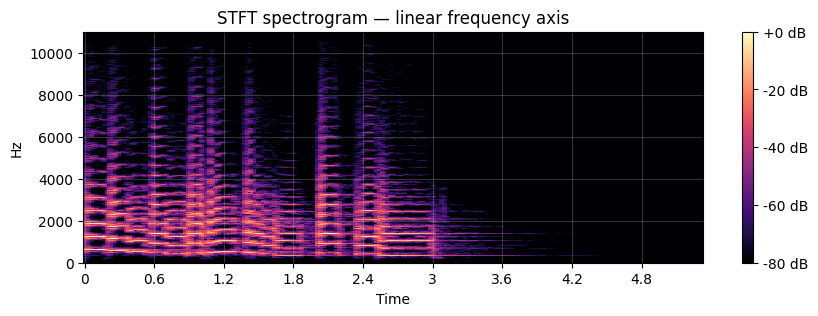

In [22]:
S = librosa.stft(y, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

fig, ax = plt.subplots()
img = librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis="time", y_axis="hz", ax=ax)
ax.set_title("STFT spectrogram — linear frequency axis")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.show()


The horizontal bands are the trumpet's harmonics. The bright vertical edges are the note attacks. You can read the music straight off the picture. Compare this to the waveform plot earlier and you'll see how much structure the spectrogram exposes that the waveform conceals.

### Seeing the trade-off

Let's make the time-versus-frequency trade-off concrete by running the same clip through three different window lengths.


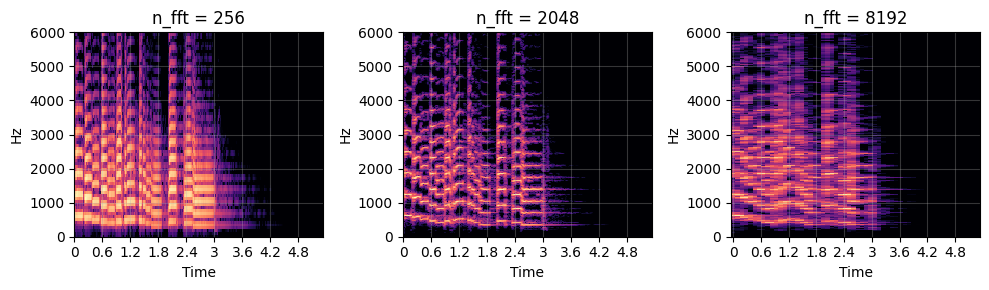

In [21]:
fig, axes = plt.subplots(1, 3)

for ax, n_fft in zip(axes, [256, 2048, 8192]):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=n_fft // 4))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=n_fft // 4, x_axis="time", y_axis="hz", ax=ax)
    ax.set_title(f"n_fft = {n_fft}")
    ax.set_ylim(0, 6000)

plt.tight_layout()
plt.show()


Left to right:

At **`n_fft=256`** the vertical edges of the attacks are sharp; we know exactly *when* each note starts but the harmonic bands are smeared into broad strips. Good time resolution, poor frequency resolution.

At **`n_fft=2048`** we have the sensible default. Attacks are clearly identifiable, harmonics are clearly distinguished. This is what we'll use throughout, and what 99% of audio ML papers use.

At **`n_fft=8192`** the harmonic lines are pin-sharp but the attacks have smeared horizontally. Excellent frequency resolution, poor time resolution. Useful for pitch-tracking, less so for tracking rhythm.

For ML classification you generally don't need the extremes either way. The default typically sits comfortably in the middle, depending on your specific task.


## 5. Mel Spectrograms :: Respecting How We Hear

There's something the linear STFT does that's wasteful for both the engineer and the model. It allocates equal resolution at 8 kHz as at 100 Hz, even though our ears can barely distinguish frequency differences in the high end with anything like the precision they bring to the low end. Human hearing typically sits between 20Hz to 20kHz, although we start losing those upper frequencies near immediately as get older. The 1000+ frequency bins of a typical STFT contain a lot of detail in the upper register that no listener could resolve and no model needs.

The auditory system is logarithmic in its frequency sensitivity, so a doubling of frequency is heard as a roughly fixed pitch interval, regardless of where on the spectrum you are. The **Mel scale** is the perceptual frequency scale that audio research seems to have settled on. It's roughly linear below 1 kHz and roughly logarithmic above, mirroring the way the cochlea actually resolves frequency.

A **Mel spectrogram** is built by computing a normal STFT and then mapping its frequency bins onto a smaller number of Mel-spaced bins, typically 64 or 128. The result is both substantially smaller than the linear STFT and perceptually weighted toward the bands that carry the information. This is what the benchmarking notebook uses, and what the vast majority of audio ML models consume as input.


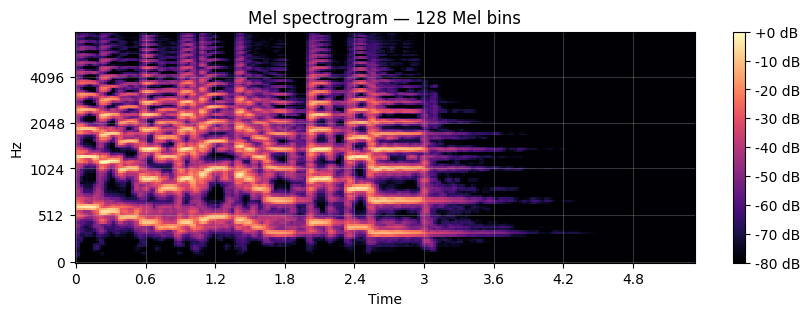

Linear STFT shape: (1025, 230) (1025 frequency bins)
Mel spectrogram: (128, 230) (128 Mel bins)


In [23]:
S_mel= librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512, fmin=20, fmax=8000)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)  

fig, ax = plt.subplots()
img = librosa.display.specshow(S_mel_db, sr=sr, hop_length=512, x_axis="time", y_axis="mel", fmax=8000, ax=ax)
ax.set_title("Mel spectrogram — 128 Mel bins")
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.show()

print(f"Linear STFT shape: {S.shape} ({S.shape[0]} frequency bins)")
print(f"Mel spectrogram: {S_mel.shape} ({S_mel.shape[0]} Mel bins)")


Two things to notice. The frequency axis is non-linear, so there's far more vertical space allocated to the low end than the high. That spacing is the Mel scale, and it's a much closer match to how we hear than the linear axis. As a consequence the data is dramatically reduced: while the linear STFT had over 1000 frequency bins per frame, the Mel spectrogram has 128. About an eighth of the size, with a lot of the perceptually-irrelevant detail thrown out.

**This two-dimensional array, `[n_mels, time_frames]`, is what the vast majority of audio ML models receive as input.** Treated as a single-channel image, it slots directly into convolutional architectures designed for vision tasks, which is why models like GhostNet and EfficientNet can be repurposed for audio with minimal changes.

One operational note worth carrying. `librosa.feature.melspectrogram` returns *power* (magnitude squared), not amplitude. Convert it to dB using `librosa.power_to_db`, not `amplitude_to_db`. Getting these the wrong way around is a fairly easy bug that leaves your features at the wrong scale and your model with no idea why it can't learn.


## 6. Filters

A **filter** is anything that boosts or attenuates certain frequencies while passing others. Four shapes come up constantly.

**Low-pass**, or *everything Lower shall Pass*, preserves low frequencies and rolls off the highs. Used to remove hiss and high-frequency noise, and as an anti-aliasing stage when reducing sample rates.

**High-pass**, or *everything Higher shall Pass*, does the opposite. Rolls off the lows, preserves the highs. This is the most useful filter in everyday preprocessing. Microphones pick up an enormous amount of low-frequency rumble: air conditioning, traffic, footsteps, breathing, and that contributes nothing to the recording. A high-pass at 50 to 80 Hz removes most of it without touching the source. This subtractive approach is, in my view, the most overlooked and underused tool in the preprocessing toolbox. Much easier to see when you come from a recording background.

**Band-pass** is the combination. Preserve a middle range, attenuate everything above and below. Useful when you know your target signal lives in a defined band. Fairly typical in EQ strips.

**Band-stop**, or **notch**, does the opposite of band-pass and removes a narrow band and preserves everything else. Used most often to kill mains power distorion, which sits at a single narrow tone of 50 or 60 Hz depending on where you are. The rule in audio is typically boost wide and cut narrow, but that's more a lesson for recording. Still, good to know.

We use `scipy.signal` for the filter design. The pattern is always the same: design the filter, then apply it.


In [25]:
def make_filter(cutoff_hz, sr, btype, order=4):
    """Design a Butterworth filter. cutoff can be a single value or a (low, high) pair."""
    return signal.butter(order, cutoff_hz, btype=btype, fs=sr, output="sos")

def apply_filter(y, sos):
    """Apply forwards and backwards for zero phase distortion."""
    return signal.sosfiltfilt(sos, y)

y_lowpass = apply_filter(y, make_filter(1000, sr, "lowpass"))
y_highpass = apply_filter(y, make_filter(1000, sr, "highpass"))
y_bandpass = apply_filter(y, make_filter([300, 3400], sr, "bandpass"))

print("Original:"); display(Audio(y, rate=sr))
print("Low-pass < 1kHz:"); display(Audio(y_lowpass, rate=sr))
print("High-pass > 1kHz:"); display(Audio(y_highpass, rate=sr))
print("Band-pass 300–3400Hz:"); display(Audio(y_bandpass, rate=sr))


Original:


Low-pass < 1kHz:


High-pass > 1kHz:


Band-pass 300–3400Hz:


Audition each one. The low-passed trumpet has lost its bite. The bright upper harmonics that give the instrument its character are gone, and what remains sounds muffled. The high-passed version is the inverse: tinny and thin, the body removed. The band-pass keeps a small slice in the middle, and, as a fun fact, this range is exactly the same as the G.711 codecs used in older telephone systems. It's exactly the same filter you want to apply if you want that "telephone" voice effect.


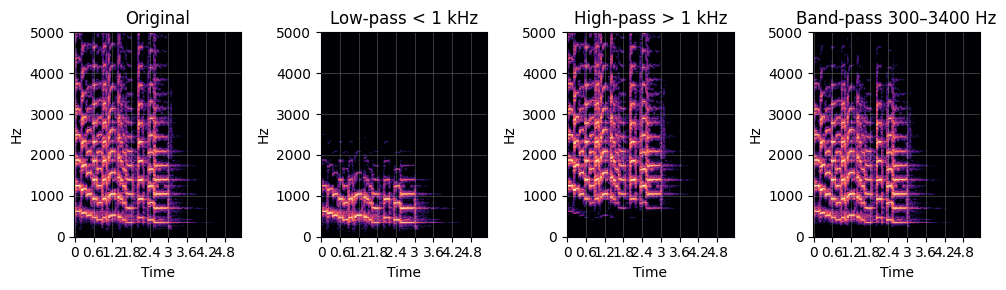

In [26]:
fig, axes = plt.subplots(1, 4)
clips = [("Original", y), ("Low-pass < 1 kHz", y_lowpass),
         ("High-pass > 1 kHz", y_highpass), ("Band-pass 300–3400 Hz", y_bandpass)]

for ax, (title, clip) in zip(axes, clips):
    S_db = librosa.amplitude_to_db(np.abs(librosa.stft(clip)), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz", ax=ax)
    ax.set_title(title)
    ax.set_ylim(0, 5000)

plt.tight_layout()
plt.show()


The dark regions show exactly where each filter has done its work. The information removed by a filter is gone, so use them to remove things you don't want, not to fix things that are broken.

### When to filter in an ML pipeline

Probably less often than you'd think, depending on the task. A modern CNN can learn to ignore frequency bands that don't carry useful information for the task. Aggressive preprocessing filters can hurt more than they help because you're removing information based on your own assumptions about what matters, and those assumptions are sometimes wrong.

There are still clear cases where filtering earns its place: known fixed interference (a notch at 50 Hz to remove mains hum); firm domain knowledge about where your target signal lives (a band-pass for bird calls that all sit between 2 and 8 kHz); and anti-aliasing when downsampling, which `librosa.resample` handles automatically.

For everything else, try without filtering first. Filter only when you have a specific reason.


## 7. Dynamic Range and Normalisation

Two unrelated processes share the name "compression" in audio, which causes endless confusion. **Dynamic-range compression** reduces the difference between the loudest and quietest parts of a signal, which is what a compressor does in a mix. **Audio file compression** (MP3, AAC) is unrelated; it reduces file size by throwing away perceptually unimportant information. Same name, different operations.

For ML preprocessing we mostly care about a secret third option: **amplitude normalisation**, which is scaling each clip so they arrive at the model at comparable levels. Imagine you're assembling a dataset and some recordings were captured with the microphone close to the source while others were captured at a distance. The content is the same but the levels are wildly different, and a model trained on this without normalisation will be trying to learn to compensate for level variation that has nothing to do with the classification task.

Let's pull a longer clip from the Brahms example to look at this, as music has more interesting dynamics than a single sustained trumpet note.


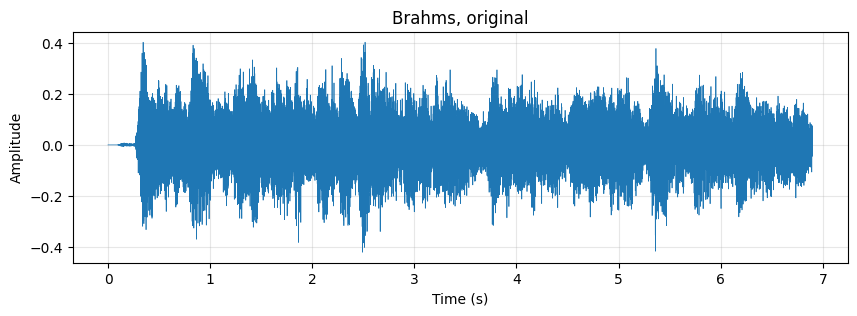

Peak: 0.420 | RMS: 0.086


In [34]:
y_music, sr_m = librosa.load(librosa.ex("brahms"), sr=22050, offset=0, duration=6.9)
times_m = np.arange(len(y_music)) / sr_m

plt.plot(times_m, y_music, linewidth=0.5)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.title("Brahms, original")
plt.show()

print(f"Peak: {np.max(np.abs(y_music)):.3f} | RMS: {np.sqrt(np.mean(y_music**2)):.3f}")
Audio(y_music, rate=sr_m)


Three sensible approaches to fixing level variation across a dataset:

#### Peak normalisation

Scale every clip so its loudest sample sits at exactly 1.0. Simple and fast, but a single brief transient at the top of an otherwise quiet clip will determine the scale factor for the whole thing, leaving the rest quieter than you'd want.


In [36]:
y_peak_norm = y_music / np.max(np.abs(y_music))

print(f"Peak normalised, peak: {np.max(np.abs(y_peak_norm)):.3f} | "
      f"RMS: {np.sqrt(np.mean(y_peak_norm**2)):.3f}")


Peak normalised, peak: 1.000 | RMS: 0.206


#### RMS normalisation

Scale every clip to a target average level. More stable across a varied dataset because brief spikes don't fool it — two clips with the same RMS will sound roughly equally loud regardless of their peak content.


In [37]:
def rms_normalise(y, target_rms=0.1):
    return y * (target_rms / (np.sqrt(np.mean(y ** 2)) + 1e-9))

y_rms_norm = rms_normalise(y_music, target_rms=0.1)
print(f"RMS normalised, peak: {np.max(np.abs(y_rms_norm)):.3f} | "
      f"RMS: {np.sqrt(np.mean(y_rms_norm**2)):.3f}")


RMS normalised, peak: 0.486 | RMS: 0.100


#### Per-feature standardisation

Once we've moved into spectrogram space, there's a third option that turns out to be cleaner and more common in practice: standardise the feature itself. Subtract the mean and divide by the standard deviation, which is basically the same operation you'd apply to a column of values in any statistical analysis. This is what the benchmarking notebook does inside its `AudioDataset`:

```python
x = (x - x.mean()) / (x.std() + 1e-6)
```

The model receives a tensor with mean zero and unit variance regardless of how loud the original recording was. It's the most robust of the three approaches because it operates on the feature representation the model actually consumes, rather than on the waveform several steps earlier in the chain.

### A word on clipping

If you boost a signal past 1.0, past digital full scale, the samples above the limit get chopped off. This is unrecoverable: the information that should have been above the limit is gone, and what's left sounds harsh and broken. Always normalise downward to a safe headroom, 0.9 or so, rather than upward to the ceiling. You might still get occasional true peaks due to digital weirdness but a single wonky sample here and there isn't the end of the world, typically.


4173 of 152145 samples would clip (2.7%)


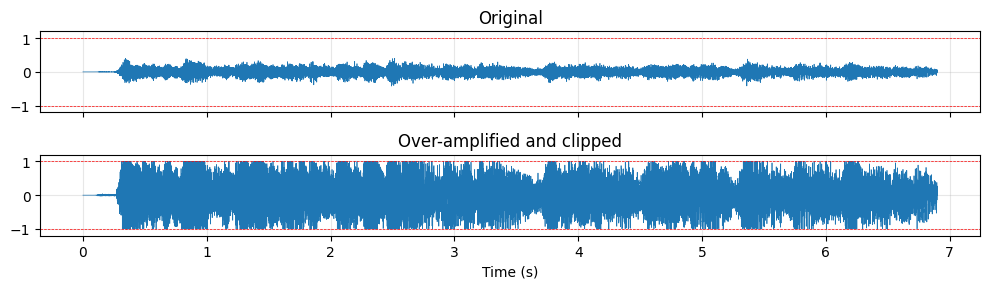

In [38]:
y_clipped_raw = y_music * 5
y_clipped = np.clip(y_clipped_raw, -1, 1)

n_clipped = np.sum(np.abs(y_clipped_raw) > 1.0)
print(f"{n_clipped} of {len(y_clipped_raw)} samples would clip ({100*n_clipped/len(y_clipped_raw):.1f}%)")

fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(times_m, y_music, linewidth=0.5);   axes[0].set_title("Original")
axes[1].plot(times_m, y_clipped, linewidth=0.5); axes[1].set_title("Over-amplified and clipped")
for ax in axes:
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(1, color="red", lw=0.5, ls="--")
    ax.axhline(-1, color="red", lw=0.5, ls="--")
axes[1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()


The flat plateaus along the top and bottom of the second plot are samples that should have been larger than $\pm$1.0 but were forced to sit at exactly $\pm$1.0 instead. Listen to it and you'll hear the harshness immediately. Better to leave the headroom and avoid it.


## 8. The Complete Pipeline

Everything we've covered combines into one short function. This is essentially what our benchmarking notebook uses inside its `cached_feature()` call, and each stage maps directly to a section above:

1. **Load and resample** to a known sample rate (Section 1)
2. **Fix the length** to pad short clips, trim long ones (Section 1)
3. **Convert to a log-Mel spectrogram** (Sections 4 and 5)
4. **Normalise** per clip (Section 7)


Feature shape: (128, 216)  (n_mels, time_frames)
Mean: 0.000   Std: 1.000


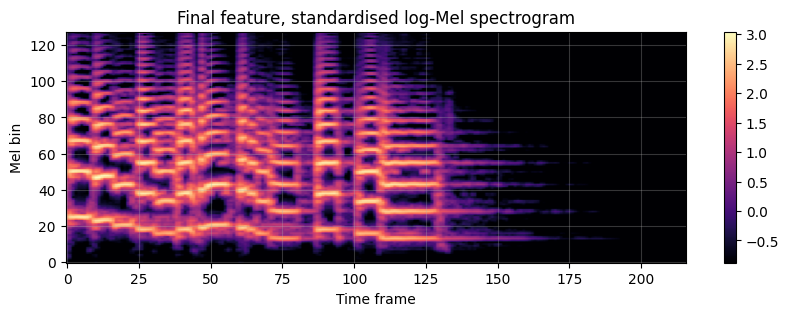

In [40]:
def extract_features(path, target_sr=22050, duration_s=5.0, n_mels=128, hop_length=512, fmin=20, fmax=8000):
    """Audio file into standardised log-Mel spectrogram ready for a model."""

    # 1. Load and resample
    y, sr = librosa.load(path, sr=target_sr, mono=True)

    # 2. Pad if short, crop if long
    target_len = int(target_sr * duration_s)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # 3. Do Log-Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                       hop_length=hop_length, fmin=fmin, fmax=fmax)
    S_db = librosa.power_to_db(S, ref=np.max)

    # 4. Do per-clip normalisation
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)

    return S_db.astype(np.float32)

features = extract_features(librosa.ex("trumpet"))
print(f"Feature shape: {features.shape}  (n_mels, time_frames)")
print(f"Mean: {features.mean():.3f}   Std: {features.std():.3f}")

fig, ax = plt.subplots()
img = ax.imshow(features, aspect="auto", origin="lower", cmap="magma")
ax.set_xlabel("Time frame"); ax.set_ylabel("Mel bin")
ax.set_title("Final feature, standardised log-Mel spectrogram")
fig.colorbar(img, ax=ax)
plt.show()


That two-dimensional array is the input to the model. Add a channel dimension and it becomes a single-channel image, which is exactly how a convolutional architecture treats it. The trumpet's structure, the attacks, sustained harmonics, decays, is still fairly legibly there, in a form that's perceptually weighted, efficient, and consistent across the dataset.

## Closing Notes

We've traced the signal from the file on disk to the tensor a model consumes, with each stage chosen rather than assumed. The same recipe handles bird calls, speech, music, machinery sounds, basically whatever the source, only the parameter choices change.

The [librosa documentation](https://librosa.org/doc/latest/) is fantastic and its gallery of examples is the place to go when you need something beyond the basics.

Above all, listen to what's going through your pipeline. If a step makes the audio sound markedly worse, ask whether the model really needs that step. If you can hear the difference between two parameter choices, the model probably can too.
